<a href="https://colab.research.google.com/github/Ehsan-Roohi/DSMC_Python/blob/main/Bijan_Model_Correct.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Please choose the collision method:
  [1] Simplified Bernoulli Trials (SBT)
  [2] Deterministic Closest-Pair (DCP)
Enter choice (1 or 2): 2
--- DSMC Relaxation to Maxwell-Boltzmann ---
--- Using Collision Method: DCP ---
--- Particles per Cell: 5 ---
Initializing particles with a UNIFORM random velocity distribution...
Velocities scaled to match initial temperature T_INIT = 273.0K.

Starting main simulation loop...
Step: 1000/10000...
Step: 2000/10000...
Step: 3000/10000...
Step: 4000/10000...
Step: 5000/10000...
Step: 6000/10000...
Step: 7000/10000...
Step: 8000/10000...
Step: 9000/10000...
Step: 10000/10000...
Simulation finished in 109.36 seconds.

Collision probability check passed (max prob = 0.000).
Final Equilibrium Temperature: 273.00 K
Plotting final speed distribution for DCP...


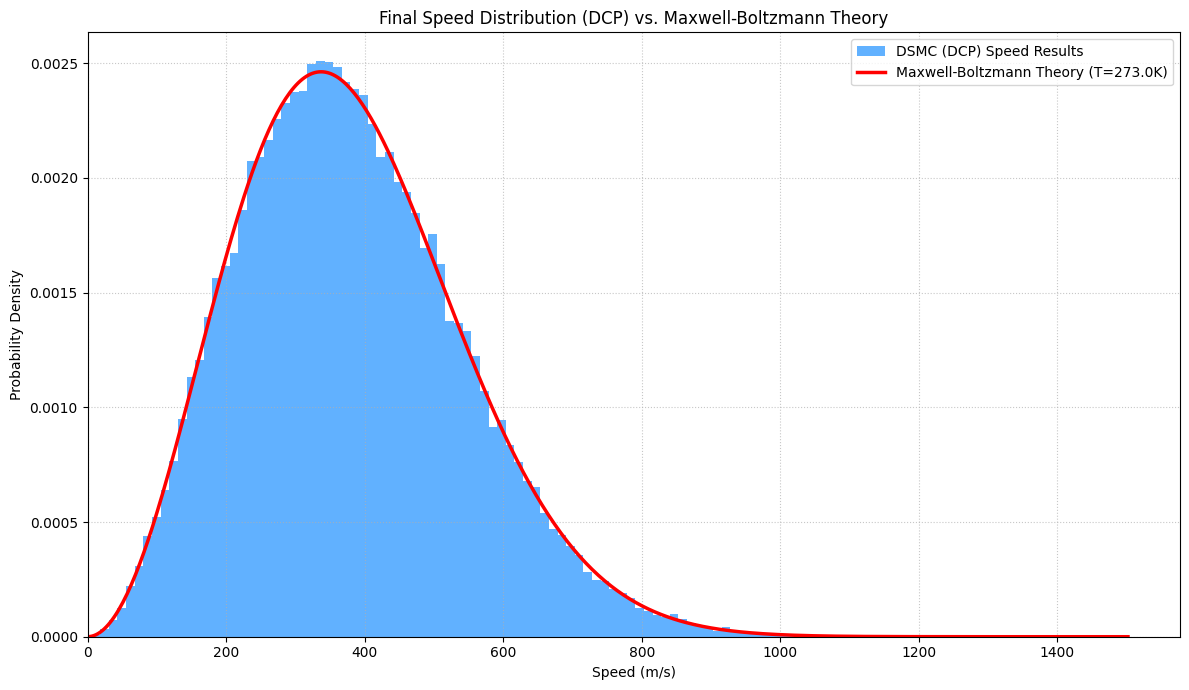

In [6]:
# -*- coding: utf-8 -*-
# --- DSMC RELAXATION - V2.1 - Interactive Choice & Updated Parameters ---
# This version prompts the user to choose a collision method and sets PPC=5.

import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.81

# --- SIMULATION PARAMETERS ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 400
PARTICLES_PER_CELL_INIT = 5  # <<< MODIFIED as per user request
TOTAL_PARTICLES_SIM = NUM_CELLS_X * PARTICLES_PER_CELL_INIT
N_DENSITY_REAL = RHO_INIT / MASS_AR
CELL_VOLUME_CONCEPTUAL = (LX**3) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 2.0e-12
TOTAL_TIME = 2.0e-8
SAMPLING_START_TIME = 5.0e-9
SAMPLING_INTERVAL = 2

# --- Initialization Function ---
def initialize_particles_non_equilibrium(rng_state):
    """Initializes particles with a uniform random velocity distribution."""
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    cell_width = LX / NUM_CELLS_X
    V_MAX_INITIAL = 800.0

    print("Initializing particles with a UNIFORM random velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX
    particles[:, 1:4] = V_MAX_INITIAL * (2.0 * rng_state.random((TOTAL_PARTICLES_SIM, 3)) - 1.0)

    current_ke = 0.5 * MASS_AR * np.sum(particles[:, 1:4]**2)
    target_ke = 1.5 * TOTAL_PARTICLES_SIM * KB * T_INIT
    scaling_factor = np.sqrt(target_ke / current_ke)
    particles[:, 1:4] *= scaling_factor

    print(f"Velocities scaled to match initial temperature T_INIT = {T_INIT}K.")
    return particles

# --- DSMC Core Functions ---

@njit(nopython=True)
def calculate_vhs_cross_section_numba(vr_mag):
    if vr_mag < 1e-9: return 1e-30
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = 1.04533
    d_sq = (D_REF_AR**2) * ((c_ref_sq / vr_mag**2)**exponent) * (1 / gamma_val)
    return np.pi * d_sq

# --- Method 1: Simplified Bernoulli Trials (SBT) ---
@njit(nopython=True)
def perform_collisions_sbt_numba(particles, indices_in_cell, cell_vol, dt, fnum, rng_state):
    max_prob_in_step = 0.0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0.0

    prob_const = fnum * dt / cell_vol
    for i in range(num_particles_in_cell):
        for j in range(i + 1, num_particles_in_cell):
            p1_idx = indices_in_cell[i]
            p2_idx = indices_in_cell[j]

            vrx, vry, vrz = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(vrx**2 + vry**2 + vrz**2)
            if vr_mag < 1e-9: continue

            sigma_t = calculate_vhs_cross_section_numba(vr_mag)
            collision_prob = prob_const * sigma_t * vr_mag
            if collision_prob > max_prob_in_step:
                max_prob_in_step = collision_prob

            if rng_state.random() < collision_prob:
                vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
                cos_chi = 2 * rng_state.random() - 1.0
                sin_chi = np.sqrt(1.0 - cos_chi**2)
                phi_chi = 2.0 * np.pi * rng_state.random()
                vr_prime = np.array([vr_mag*sin_chi*np.cos(phi_chi), vr_mag*sin_chi*np.sin(phi_chi), vr_mag*cos_chi])
                particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
                particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return max_prob_in_step

# --- Method 2: Deterministic Closest-Pair (DCP) ---
@njit
def generate_pairs_and_weights_distance(indices_in_cell, x_all, epsilon=1e-10):
    Nc = len(indices_in_cell)
    if Nc < 2: return np.empty((0, 2), dtype=np.int32), np.empty(0, dtype=np.float64)
    max_pairs = Nc * (Nc - 1) // 2
    pairs = np.empty((max_pairs, 2), dtype=np.int32)
    weights = np.empty(max_pairs, dtype=np.float64)
    pair_count = 0
    for i in range(Nc):
        p_a_id = indices_in_cell[i]
        for k in range(i + 1, Nc):
            p_b_id = indices_in_cell[k]
            distance = np.abs(x_all[p_a_id] - x_all[p_b_id])
            weights[pair_count] = 1.0 / (distance + epsilon)
            pairs[pair_count, 0] = p_a_id
            pairs[pair_count, 1] = p_b_id
            pair_count += 1
    return pairs[:pair_count], weights[:pair_count]

@njit
def classical_sample_pair_index_from_weights(weights, rng_state):
    if len(weights) == 0: return -1
    weights_sum = np.sum(weights)
    if weights_sum <= 1e-12: return -1
    probabilities = weights / weights_sum
    cumulative_probabilities = np.cumsum(probabilities)
    rand_val = rng_state.uniform(0.0, 1.0)
    return np.searchsorted(cumulative_probabilities, rand_val, side='right')

@njit(nopython=True)
def perform_collisions_dcp_numba(particles, indices_in_cell, cell_vol, dt, fnum, rng_state):
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0.0

    pairs, weights = generate_pairs_and_weights_distance(indices_in_cell, particles[:, 0])
    if len(pairs) == 0: return 0.0

    sum_of_sigma_g = 0.0
    for i in range(len(pairs)):
        p1_idx, p2_idx = pairs[i]
        vrx, vry, vrz = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(vrx**2 + vry**2 + vrz**2)
        if vr_mag > 1e-9:
            sum_of_sigma_g += calculate_vhs_cross_section_numba(vr_mag) * vr_mag

    expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
    num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))

    if num_collisions_to_perform <= 0: return 0.0

    for _ in range(num_collisions_to_perform):
        if np.sum(weights) < 1e-12: break

        selected_idx = classical_sample_pair_index_from_weights(weights, rng_state)
        if selected_idx == -1: continue

        p1_idx, p2_idx = pairs[selected_idx]

        vrx, vry, vrz = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(vrx**2 + vry**2 + vrz**2)
        if vr_mag < 1e-9: continue

        vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
        cos_chi = 2 * rng_state.random() - 1.0
        sin_chi = np.sqrt(1.0 - cos_chi**2)
        phi_chi = 2.0 * np.pi * rng_state.random()
        vr_prime = np.array([vr_mag*sin_chi*np.cos(phi_chi), vr_mag*sin_chi*np.sin(phi_chi), vr_mag*cos_chi])
        particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
        particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime

        weights[selected_idx] = 0.0

    return 0.0

# --- Plotting Function ---
def plot_speed_distribution(sampled_speeds, final_temp, method_name):
    print(f"Plotting final speed distribution for {method_name}...")
    plt.figure(figsize=(12, 7))
    plt.hist(sampled_speeds, bins=100, density=True, label=f'DSMC ({method_name}) Speed Results', alpha=0.7, color='dodgerblue')
    v_max_range = np.max(sampled_speeds) * 1.2
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * np.pi * KB * final_temp))**1.5 * 4 * np.pi * v_theory**2
                 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    plt.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Maxwell-Boltzmann Theory (T={final_temp:.1f}K)')
    plt.xlabel('Speed (m/s)'); plt.ylabel('Probability Density')
    plt.title(f'Final Speed Distribution ({method_name}) vs. Maxwell-Boltzmann Theory')
    plt.legend(); plt.grid(True, linestyle=':', alpha=0.7)
    plt.xlim(left=0); plt.ylim(bottom=0)
    plt.tight_layout(); plt.show()

# --- Main Simulation Driver ---
def run_dsmc_simulation(collision_method='SBT'):
    print(f"--- DSMC Relaxation to Maxwell-Boltzmann ---")
    print(f"--- Using Collision Method: {collision_method} ---")
    print(f"--- Particles per Cell: {PARTICLES_PER_CELL_INIT} ---")

    rng_state = np.random.default_rng()
    particles = initialize_particles_non_equilibrium(rng_state)

    sampled_speeds_accumulator = []
    max_overall_prob = 0.0

    start_time = time.time()
    print("\nStarting main simulation loop...")
    num_steps = int(TOTAL_TIME / DT)
    sampling_start_step = int(SAMPLING_START_TIME / DT)
    cell_width = LX / NUM_CELLS_X

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX

        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)
        sorted_particle_indices = np.argsort(cell_indices)
        cell_counts = np.bincount(cell_indices, minlength=NUM_CELLS_X)
        cell_start_indices = np.concatenate(([0], np.cumsum(cell_counts[:-1])))

        current_max_prob = 0.0
        for i in range(NUM_CELLS_X):
            start = cell_start_indices[i]
            end = start + cell_counts[i]
            indices_in_cell_i = sorted_particle_indices[start:end]

            if collision_method == 'SBT':
                max_p = perform_collisions_sbt_numba(particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state)
            elif collision_method == 'DCP':
                max_p = perform_collisions_dcp_numba(particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state)
            else:
                max_p = 0.0

            if max_p > current_max_prob:
                current_max_prob = max_p

        if current_max_prob > max_overall_prob:
            max_overall_prob = current_max_prob

        if step >= sampling_start_step and step % SAMPLING_INTERVAL == 0:
            speeds = np.sqrt(np.sum(particles[:, 1:4]**2, axis=1))
            sampled_speeds_accumulator.extend(speeds)

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps}...")

    end_time = time.time()
    print(f"Simulation finished in {end_time - start_time:.2f} seconds.\n")

    if max_overall_prob > 1.0:
        print(f"WARNING: Maximum collision probability reached {max_overall_prob:.3f}.")
        print("This is unphysical. The time step (DT) should be reduced.")
    else:
        print(f"Collision probability check passed (max prob = {max_overall_prob:.3f}).")

    final_temp = (2.0/3.0) * (0.5 * MASS_AR * np.sum(particles[:, 1:4]**2) / TOTAL_PARTICLES_SIM) / KB
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")

    if sampled_speeds_accumulator:
        plot_speed_distribution(np.array(sampled_speeds_accumulator), final_temp, collision_method)
    else:
        print("No speed data was sampled. Check SAMPLING_START_TIME and TOTAL_TIME.")

# ===================================================================
if __name__ == "__main__":
    # <<< MODIFIED: Interactive choice for collision method >>>
    while True:
        choice = input("Please choose the collision method:\n  [1] Simplified Bernoulli Trials (SBT)\n  [2] Deterministic Closest-Pair (DCP)\nEnter choice (1 or 2): ")
        if choice == '1':
            SELECTED_METHOD = 'SBT'
            break
        elif choice == '2':
            SELECTED_METHOD = 'DCP'
            break
        else:
            print("Invalid input. Please enter 1 or 2.")

    run_dsmc_simulation(collision_method=SELECTED_METHOD)

In [ ]:
# -*- coding: utf-8 -*-
# --- DSMC RELAXATION - V2.2 - Final Complete & Corrected Code ---
# This version is a complete, runnable script with an interactive choice
# for the collision method and corrected decorators to prevent warnings.

import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.81

# --- SIMULATION PARAMETERS (can be modified here) ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 800
PARTICLES_PER_CELL_INIT = 5  # As per user request
TOTAL_PARTICLES_SIM = NUM_CELLS_X * PARTICLES_PER_CELL_INIT
N_DENSITY_REAL = RHO_INIT / MASS_AR
CELL_VOLUME_CONCEPTUAL = (LX**3) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 2.0e-8
SAMPLING_START_TIME = 5.0e-9
SAMPLING_INTERVAL = 2

# --- Initialization Function ---
def initialize_particles_non_equilibrium(rng_state):
    """Initializes particles with a uniform random velocity distribution."""
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    cell_width = LX / NUM_CELLS_X
    V_MAX_INITIAL = 800.0

    print("Initializing particles with a UNIFORM random velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX
    particles[:, 1:4] = V_MAX_INITIAL * (2.0 * rng_state.random((TOTAL_PARTICLES_SIM, 3)) - 1.0)

    current_ke = 0.5 * MASS_AR * np.sum(particles[:, 1:4]**2)
    target_ke = 1.5 * TOTAL_PARTICLES_SIM * KB * T_INIT
    if current_ke > 1e-12: # Avoid division by zero if all velocities happen to be zero
        scaling_factor = np.sqrt(target_ke / current_ke)
        particles[:, 1:4] *= scaling_factor

    print(f"Velocities scaled to match initial temperature T_INIT = {T_INIT}K.")
    return particles

# --- DSMC Core Functions ---

@njit
def calculate_vhs_cross_section_numba(vr_mag):
    """Calculates the collision cross-section using the VHS model."""
    if vr_mag < 1e-9: return 1e-30
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = 1.04533
    d_sq = (D_REF_AR**2) * ((c_ref_sq / vr_mag**2)**exponent) * (1 / gamma_val)
    return np.pi * d_sq

# --- Method 1: Simplified Bernoulli Trials (SBT) ---
@njit
def perform_collisions_sbt_numba(particles, indices_in_cell, cell_vol, dt, fnum, rng_state):
    """Performs collisions in a cell using the Simplified Bernoulli Trials (SBT) scheme."""
    max_prob_in_step = 0.0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0.0

    prob_const = fnum * dt / cell_vol
    for i in range(num_particles_in_cell):
        for j in range(i + 1, num_particles_in_cell):
            p1_idx = indices_in_cell[i]
            p2_idx = indices_in_cell[j]

            vrx, vry, vrz = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(vrx**2 + vry**2 + vrz**2)
            if vr_mag < 1e-9: continue

            sigma_t = calculate_vhs_cross_section_numba(vr_mag)
            collision_prob = prob_const * sigma_t * vr_mag
            if collision_prob > max_prob_in_step:
                max_prob_in_step = collision_prob

            if rng_state.random() < collision_prob:
                vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
                cos_chi = 2 * rng_state.random() - 1.0
                sin_chi = np.sqrt(1.0 - cos_chi**2)
                phi_chi = 2.0 * np.pi * rng_state.random()
                vr_prime = np.array([vr_mag*sin_chi*np.cos(phi_chi), vr_mag*sin_chi*np.sin(phi_chi), vr_mag*cos_chi])
                particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
                particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return max_prob_in_step

# --- Method 2: Deterministic Closest-Pair (DCP) ---
@njit
def generate_pairs_and_weights_distance(indices_in_cell, x_all, epsilon=1e-10):
    Nc = len(indices_in_cell)
    if Nc < 2: return np.empty((0, 2), dtype=np.int32), np.empty(0, dtype=np.float64)
    max_pairs = Nc * (Nc - 1) // 2
    pairs = np.empty((max_pairs, 2), dtype=np.int32)
    weights = np.empty(max_pairs, dtype=np.float64)
    pair_count = 0
    for i in range(Nc):
        p_a_id = indices_in_cell[i]
        for k in range(i + 1, Nc):
            p_b_id = indices_in_cell[k]
            distance = np.abs(x_all[p_a_id] - x_all[p_b_id])
            weights[pair_count] = 1.0 / (distance + epsilon)
            pairs[pair_count, 0] = p_a_id
            pairs[pair_count, 1] = p_b_id
            pair_count += 1
    return pairs[:pair_count], weights[:pair_count]

@njit
def classical_sample_pair_index_from_weights(weights, rng_state):
    if len(weights) == 0: return -1
    weights_sum = np.sum(weights)
    if weights_sum <= 1e-12: return -1
    probabilities = weights / weights_sum
    cumulative_probabilities = np.cumsum(probabilities)
    rand_val = rng_state.uniform(0.0, 1.0)
    return np.searchsorted(cumulative_probabilities, rand_val, side='right')

@njit
def perform_collisions_dcp_numba(particles, indices_in_cell, cell_vol, dt, fnum, rng_state):
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0.0

    pairs, weights = generate_pairs_and_weights_distance(indices_in_cell, particles[:, 0])
    if len(pairs) == 0: return 0.0

    sum_of_sigma_g = 0.0
    for i in range(len(pairs)):
        p1_idx, p2_idx = pairs[i]
        vrx, vry, vrz = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(vrx**2 + vry**2 + vrz**2)
        if vr_mag > 1e-9:
            sum_of_sigma_g += calculate_vhs_cross_section_numba(vr_mag) * vr_mag

    expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
    num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))

    if num_collisions_to_perform <= 0: return 0.0

    for _ in range(num_collisions_to_perform):
        if np.sum(weights) < 1e-12: break

        selected_idx = np.argmax(weights) # Deterministic selection

        p1_idx, p2_idx = pairs[selected_idx]

        vrx, vry, vrz = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(vrx**2 + vry**2 + vrz**2)
        if vr_mag < 1e-9:
            weights[selected_idx] = 0.0 # Mark as unusable
            continue

        vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
        cos_chi = 2 * rng_state.random() - 1.0
        sin_chi = np.sqrt(1.0 - cos_chi**2)
        phi_chi = 2.0 * np.pi * rng_state.random()
        vr_prime = np.array([vr_mag*sin_chi*np.cos(phi_chi), vr_mag*sin_chi*np.sin(phi_chi), vr_mag*cos_chi])
        particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
        particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime

        weights[selected_idx] = 0.0

    return 0.0

# --- Plotting Function ---
def plot_speed_distribution(sampled_speeds, final_temp, method_name):
    """Plots the final speed distribution histogram against the theoretical Maxwell-Boltzmann curve."""
    print(f"Plotting final speed distribution for {method_name}...")
    plt.figure(figsize=(12, 7))
    plt.hist(sampled_speeds, bins=100, density=True, label=f'DSMC ({method_name}) Speed Results', alpha=0.7, color='dodgerblue')
    v_max_range = np.max(sampled_speeds) * 1.2
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * np.pi * KB * final_temp))**1.5 * 4 * np.pi * v_theory**2
                 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    plt.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Maxwell-Boltzmann Theory (T={final_temp:.1f}K)')
    plt.xlabel('Speed (m/s)'); plt.ylabel('Probability Density')
    plt.title(f'Final Speed Distribution ({method_name}) vs. Maxwell-Boltzmann Theory')
    plt.legend(); plt.grid(True, linestyle=':', alpha=0.7)
    plt.xlim(left=0); plt.ylim(bottom=0)
    plt.tight_layout(); plt.show()

# --- Main Simulation Driver ---
def run_dsmc_simulation(collision_method='SBT'):
    """Main DSMC simulation loop with selectable collision method."""
    print(f"--- DSMC Relaxation to Maxwell-Boltzmann ---")
    print(f"--- Using Collision Method: {collision_method} ---")
    print(f"--- Particles per Cell: {PARTICLES_PER_CELL_INIT} ---")

    rng_state = np.random.default_rng()
    particles = initialize_particles_non_equilibrium(rng_state)

    sampled_speeds_accumulator = []
    max_overall_prob = 0.0

    start_time = time.time()
    print("\nStarting main simulation loop...")
    num_steps = int(TOTAL_TIME / DT)
    sampling_start_step = int(SAMPLING_START_TIME / DT)
    cell_width = LX / NUM_CELLS_X

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX

        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)
        sorted_particle_indices = np.argsort(cell_indices)
        cell_counts = np.bincount(cell_indices, minlength=NUM_CELLS_X)
        cell_start_indices = np.concatenate((np.array([0]), np.cumsum(cell_counts[:-1])))

        current_max_prob = 0.0
        for i in range(NUM_CELLS_X):
            start = cell_start_indices[i]
            end = start + cell_counts[i]
            indices_in_cell_i = sorted_particle_indices[start:end]

            # <<< SELECTION OF COLLISION METHOD >>>
            if collision_method == 'SBT':
                max_p = perform_collisions_sbt_numba(particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state)
            elif collision_method == 'DCP':
                max_p = perform_collisions_dcp_numba(particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state)
            else: # Default to SBT if a wrong method is specified
                max_p = perform_collisions_sbt_numba(particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state)

            if max_p > current_max_prob:
                current_max_prob = max_p

        if current_max_prob > max_overall_prob:
            max_overall_prob = current_max_prob

        if step >= sampling_start_step and step % SAMPLING_INTERVAL == 0:
            speeds = np.sqrt(np.sum(particles[:, 1:4]**2, axis=1))
            sampled_speeds_accumulator.extend(speeds)

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps}...")

    end_time = time.time()
    print(f"Simulation finished in {end_time - start_time:.2f} seconds.\n")

    if max_overall_prob > 1.0:
        print(f"WARNING: Maximum collision probability reached {max_overall_prob:.3f}.")
        print("This is unphysical. The time step (DT) should be reduced.")
    else:
        print(f"Collision probability check passed (max prob = {max_overall_prob:.3f}).")

    final_temp = (2.0/3.0) * (0.5 * MASS_AR * np.sum(particles[:, 1:4]**2) / TOTAL_PARTICLES_SIM) / KB
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")

    if sampled_speeds_accumulator:
        plot_speed_distribution(np.array(sampled_speeds_accumulator), final_temp, collision_method)
    else:
        print("No speed data was sampled. Check SAMPLING_START_TIME and TOTAL_TIME.")

# ===================================================================
if __name__ == "__main__":
    # --- Interactive choice for collision method ---
    while True:
        choice = input("Please choose the collision method:\n  [1] Simplified Bernoulli Trials (SBT)\n  [2] Deterministic Closest-Pair (DCP)\nEnter choice (1 or 2): ")
        if choice == '1':
            SELECTED_METHOD = 'SBT'
            break
        elif choice == '2':
            SELECTED_METHOD = 'DCP'
            break
        else:
            print("Invalid input. Please enter 1 or 2.")

    run_dsmc_simulation(collision_method=SELECTED_METHOD)

Please choose the collision method:
  [1] Simplified Bernoulli Trials (SBT)
  [2] Deterministic Closest-Pair (DCP)
Enter choice (1 or 2): 2
--- DSMC Relaxation to Maxwell-Boltzmann ---
--- Using Collision Method: DCP ---
--- Particles per Cell: 5 ---
Initializing particles with a UNIFORM random velocity distribution...
Velocities scaled to match initial temperature T_INIT = 273.0K.

Starting main simulation loop...
Step: 2000/20000...


/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Please choose the collision method:
  [1] Simplified Bernoulli Trials (SBT)
  [2] Deterministic Closest-Pair (DCP)
Enter choice (1 or 2): 2
--- DSMC Relaxation to Maxwell-Boltzmann ---
--- Using Collision Method: DCP ---
--- Particles per Cell: 5 ---

Starting main simulation loop...
Step: 1499/14999...
Step: 2998/14999...
Step: 4497/14999...
Step: 5996/14999...
Step: 7495/14999...
Step: 8994/14999...
Step: 10493/14999...
Step: 11992/14999...
Step: 13491/14999...
Step: 14990/14999...
Simulation finished in 146.89 seconds.

Collision probability check passed (max prob = 0.000).
Final Equilibrium Temperature: 262.48 K


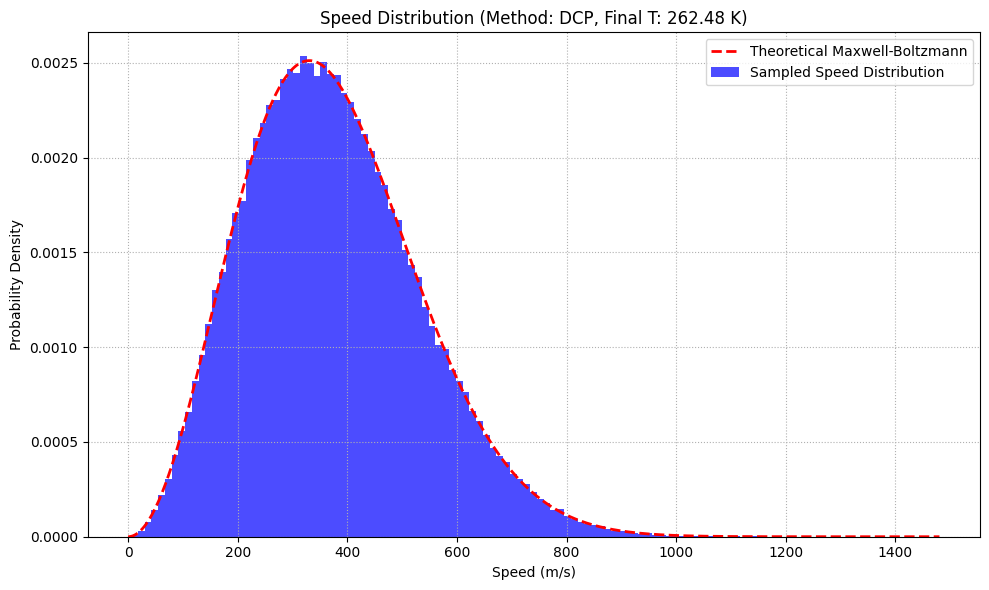

In [1]:
# -*- coding: utf-8 -*-
# --- DSMC RELAXATION - V2.1 - Interactive Choice & Updated Parameters ---
# This version prompts the user to choose a collision method and sets PPC=5.

import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit, prange # Ensure prange is imported for parallel loops
import time
from scipy.signal import savgol_filter
import pandas as pd
import warnings # Import the warnings module
from numba.core.errors import NumbaPerformanceWarning # For Numba specific warnings

# Suppress the specific NumbaPerformanceWarning
warnings.simplefilter('ignore', category=NumbaPerformanceWarning)
# Suppress RuntimeWarning for "Mean of empty slice"
warnings.filterwarnings("ignore", message="Mean of empty slice", category=RuntimeWarning)


# --- Constants and Physical Parameters ---
KB = 1.380649e-23  # Boltzmann constant (J/K)
MASS_AR = 39.948e-3 / 6.022e23 # Mass of Argon atom (kg)
D_REF_AR = 4.17e-10      # Diameter of Argon atom (m) - collision cross-section (used as sigma in quantumWeighted)
T_REF_AR = 273.0
OMEGA_VHS = 0.81

# --- SIMULATION PARAMETERS ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 400
PARTICLES_PER_CELL_INIT = 5  # <<< MODIFIED as per user request
TOTAL_PARTICLES_SIM = NUM_CELLS_X * PARTICLES_PER_CELL_INIT
N_DENSITY_REAL = RHO_INIT / MASS_AR
CELL_VOLUME_CONCEPTUAL = (LX**3) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 2.0e-12
TOTAL_TIME = 3.0e-8
SAMPLING_START_TIME = 5.0e-9
SAMPLING_INTERVAL = 2

# --- Helper functions from Expansion_HighestWeight.py (needed for perform_collisions_low_density_vhs_biased logic) ---

@njit
def generate_pairs_and_weights_distance_based(cell_particles_list, cell_counts, ci, cj, x_all, y_all, vx, vy, vz, epsilon=1e-10, distance_bias_power=1.0):
    """
    Generates all unique pairs within a cell and calculates their weights based on distance.
    Higher weight reflects closer distances.

    Args:
        cell_particles_list: 3D array of particle IDs in cells.
        cell_counts: 2D array of particle counts per cell.
        ci, cj: Cell indices.
        x_all, y_all: Global arrays of all particle x and y positions.
        vx, vy, vz: Global arrays of all particle velocities (needed for relative speed, if combined).
        epsilon: Small value to prevent division by zero for identical positions.
        distance_bias_power: Exponent to control the strength of the distance bias.
                             A higher value means a stronger bias towards closer particles.

    Returns:
        pairs: 2D array of particle ID pairs.
        weights: 1D array of weights for each pair.
    """
    Nc = cell_counts[ci, cj]
    if Nc < 2:
        return np.empty((0, 2), dtype=np.int32), np.empty(0, dtype=np.float64)
    max_pairs = Nc * (Nc - 1) // 2
    pairs = np.empty((max_pairs, 2), dtype=np.int32)
    weights = np.empty(max_pairs, dtype=np.float64)
    pair_count = 0
    for i in range(Nc):
        p_a_id = cell_particles_list[ci, cj, i]
        if p_a_id == -1:
            continue
        for k in range(i + 1, Nc):
            p_b_id = cell_particles_list[ci, cj, k]
            if p_b_id == -1:
                continue
            dist_x = x_all[p_a_id] - x_all[p_b_id]
            dist_y = y_all[p_a_id] - y_all[p_b_id]
            distance = np.sqrt(dist_x**2 + dist_y**2)

            denominator = (distance + epsilon)
            if denominator < 1e-12:
                denominator = 1e-12

            weight = 1.0 / (denominator**distance_bias_power)

            pairs[pair_count, 0] = p_a_id
            pairs[pair_count, 1] = p_b_id
            weights[pair_count] = weight
            pair_count += 1
    return pairs[:pair_count], weights[:pair_count]

@njit(parallel=True)
def build_cell_particle_lists(cell_indices, N, Nx, Ny, max_particles_per_cell):
    """
    Populates arrays that store particle IDs within each cell.
    Returns cell_counts (number of particles in each cell) and cell_particles (particle IDs).
    This function is generic and works for Ny=1 naturally.
    """
    cell_counts = np.zeros((Nx, Ny), dtype=np.int32)
    cell_particles = -1 * np.ones((Nx, Ny, max_particles_per_cell), dtype=np.int32)

    for p_idx in range(N):
        ci = cell_indices[p_idx]
        cj = 0 # For 1D simulation, y-cell index is always 0
        current_count = cell_counts[ci, cj]
        if current_count < max_particles_per_cell:
            cell_particles[ci, cj, current_count] = p_idx
            cell_counts[ci, cj] += 1
    return cell_counts, cell_particles

# --- VHS cross-section (adapted to use constants from maxwel.py) ---
@njit(nopython=True)
def calculate_vhs_cross_section_numba(vr_mag):
    """Calculates the collision cross-section using the VHS model."""
    if vr_mag < 1e-9: return 1e-30
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = 1.04533
    d_sq = (D_REF_AR**2) * ((c_ref_sq / vr_mag**2)**exponent) * (1 / gamma_val)
    return np.pi * d_sq

# --- Maxwell-Boltzmann distribution and related functions ---
@njit
def maxwell_boltzmann_velocity(temperature, mass, rng_state):
    """Generates a velocity component from a Maxwell-Boltzmann distribution."""
    sigma_v = np.sqrt(KB * temperature / mass)
    return rng_state.normal(0.0, sigma_v)

@njit
def initialize_particles_non_equilibrium(rng_state):
    """Initializes particles with a non-equilibrium velocity distribution (e.g., cold at one end, hot at other)."""
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4), dtype=np.float64) # x, vx, vy, vz

    # Simple uniform spatial distribution for now
    # FIX: Numba does not support 'endpoint=False' for np.linspace.
    # Use np.arange and scale to achieve the same result.
    particles[:, 0] = np.arange(TOTAL_PARTICLES_SIM) * (LX / TOTAL_PARTICLES_SIM) # X positions

    # Initial velocities from Maxwell-Boltzmann distribution at T_INIT
    for i in range(TOTAL_PARTICLES_SIM):
        particles[i, 1] = maxwell_boltzmann_velocity(T_INIT, MASS_AR, rng_state) # vx
        particles[i, 2] = maxwell_boltzmann_velocity(T_INIT, MASS_AR, rng_state) # vy
        particles[i, 3] = maxwell_boltzmann_velocity(T_INIT, MASS_AR, rng_state) # vz

    # Center the velocities to remove any bulk velocity
    mean_vx = np.mean(particles[:, 1])
    mean_vy = np.mean(particles[:, 2])
    mean_vz = np.mean(particles[:, 3])
    particles[:, 1] -= mean_vx
    particles[:, 2] -= mean_vy
    particles[:, 3] -= mean_vz

    return particles

@njit
def classical_sample_pair_index_from_weights(weights, rng_state):
    """
    Samples an index from a given array of weights using classical method.
    Returns the index or -1 if no valid index can be sampled.
    """
    if len(weights) == 0 or np.sum(weights) == 0:
        return -1

    cumulative_weights = np.cumsum(weights)
    total_weight = cumulative_weights[-1]

    if total_weight <= 0: # Avoid issues with all zero or negative weights
        return -1

    rand_val = rng_state.random() * total_weight

    # Find the index where rand_val falls
    for idx in range(len(cumulative_weights)):
        if rand_val < cumulative_weights[idx]:
            return idx
    return -1 # Should ideally not be reached if total_weight > 0


@njit(nopython=True)
def perform_collisions_sbt_numba(particles, indices_in_cell, cell_vol, dt, fnum, rng_state):
    """
    Performs collisions in a single cell using the Simplified Bernoulli Trials (SBT) method.
    Adapted for 1D cell structure where Ny=1.
    """
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0.0 # No collisions possible

    # Collect all possible pairs and their collision probabilities
    possible_pairs = []
    collision_probabilities = []

    max_prob_in_step = 0.0

    for i in range(num_particles_in_cell):
        p_a_id = indices_in_cell[i]
        for j in range(i + 1, num_particles_in_cell):
            p_b_id = indices_in_cell[j]

            # Calculate relative velocity
            vr_x = particles[p_a_id, 1] - particles[p_b_id, 1]
            vr_y = particles[p_a_id, 2] - particles[p_b_id, 2]
            vr_z = particles[p_a_id, 3] - particles[p_b_id, 3]
            vr_mag = np.sqrt(vr_x**2 + vr_y**2 + vr_z**2)

            if vr_mag < 1e-9: # Avoid division by zero for stationary particles
                continue

            # Calculate collision cross-section (VHS model)
            sigma_t_vhs = calculate_vhs_cross_section_numba(vr_mag)

            # Calculate collision probability for this pair
            pair_prob = (fnum * sigma_t_vhs * vr_mag * dt) / cell_vol

            if pair_prob > max_prob_in_step:
                max_prob_in_step = pair_prob

            possible_pairs.append((p_a_id, p_b_id))
            collision_probabilities.append(pair_prob)

    # Perform Bernoulli trials for each pair
    if max_prob_in_step > 0:
        for k in range(len(possible_pairs)):
            if rng_state.random() < collision_probabilities[k] / max_prob_in_step:
                # Collision occurs for this pair
                p_a_id, p_b_id = possible_pairs[k]

                vr_x = particles[p_a_id, 1] - particles[p_b_id, 1]
                vr_y = particles[p_a_id, 2] - particles[p_b_id, 2]
                vr_z = particles[p_a_id, 3] - particles[p_b_id, 3]
                vr_mag = np.sqrt(vr_x**2 + vr_y**2 + vr_z**2)

                # Inelastic collision for Maxwell molecules, just change direction
                # For VHS, we use standard collision mechanics
                vcm = 0.5 * (particles[p_a_id, 1:4] + particles[p_b_id, 1:4])

                # Random angles for post-collision relative velocity
                cos_chi = 2 * rng_state.random() - 1.0
                sin_chi = np.sqrt(1.0 - cos_chi**2)
                phi_chi = 2.0 * np.pi * rng_state.random()

                # New relative velocity components
                vr_prime = np.array([
                    vr_mag * sin_chi * np.cos(phi_chi),
                    vr_mag * sin_chi * np.sin(phi_chi),
                    vr_mag * cos_chi
                ])

                # Assign new velocities
                particles[p_a_id, 1:4] = vcm + 0.5 * vr_prime
                particles[p_b_id, 1:4] = vcm - 0.5 * vr_prime

    return max_prob_in_step


@njit(nopython=True)
def perform_collisions_dcp_numba(particles, indices_in_cell, cell_vol, dt, fnum, rng_state,
                                 fractional_collisions_accumulator, collision_separation_sum_per_cell,
                                 collision_count_per_cell, ci_current, cj_current): # Added ci_current, cj_current
    """
    Performs collisions for a single cell using the distance-biased pair selection
    and VHS collision mechanics, exactly like perform_collisions_low_density_vhs_biased.
    MODIFIED: Selects the pair with the maximum weight (closest pair) for each collision.
    """
    # For compatibility, we'll treat indices_in_cell as the particles in a single cell.
    # We need to create dummy cell_particles_list_3d and cell_counts_2d for generate_pairs_and_weights_distance_based
    # This assumes we are calling this function per cell, as perform_collisions_low_density_vhs_biased expects.
    # The current structure of maxwel.py iterates through cells, so this fits.

    num_particles_in_main_cell = len(indices_in_cell)

    if num_particles_in_main_cell < 2:
        return 0.0 # Return 0.0 for max_prob_in_step compatibility with maxwel.py

    # Create dummy cell_particles_list_3d and cell_counts_2d for the current cell
    # This is a bit of a workaround to use the existing `generate_pairs_and_weights_distance_based`
    # which expects a 3D list and 2D counts.
    # Since we are already processing one cell (i.e., indices_in_cell),
    # we can construct a minimal cell_particles_list_3d and cell_counts_2d for it.
    max_particles_per_cell_buffer = num_particles_in_main_cell # Buffer size just for this cell's particles
    dummy_cell_particles_list_3d = -1 * np.ones((1, 1, max_particles_per_cell_buffer), dtype=np.int32)
    dummy_cell_counts_2d = np.zeros((1, 1), dtype=np.int32)

    if num_particles_in_main_cell > 0:
        dummy_cell_particles_list_3d[0, 0, :num_particles_in_main_cell] = indices_in_cell
        dummy_cell_counts_2d[0, 0] = num_particles_in_main_cell

    # Parameters for generate_pairs_and_weights_distance_based
    ci_dummy = 0 # Dummy index for the single cell being processed within generate_pairs_and_weights_distance_based
    cj_dummy = 0 # Dummy index for the single cell being processed within generate_pairs_and_weights_distance_based
    epsilon_val = 1e-10
    distance_bias_power = 2.0 # Default from Expansion_HighestWeight.py example

    pairs, weights = generate_pairs_and_weights_distance_based(
        dummy_cell_particles_list_3d, dummy_cell_counts_2d, ci_dummy, cj_dummy, # Use dummy indices here
        particles[:, 0], np.zeros_like(particles[:, 0]), # x_all, dummy y_all (for 1D sim)
        particles[:, 1], particles[:, 2], particles[:, 3], # vx, vy, vz
        epsilon=epsilon_val,
        distance_bias_power=distance_bias_power
    )

    if len(pairs) == 0:
        return 0.0 # Return 0.0 for max_prob_in_step compatibility

    # Recalculate sum of (VHS cross-section * relative velocities) for the NTC collision count
    sum_of_sigma_g_for_ntc = 0.0
    for pair_idx in range(len(pairs)):
        p_a_id, p_b_id = pairs[pair_idx]
        vr_x = particles[p_a_id, 1] - particles[p_b_id, 1]
        vr_y = particles[p_a_id, 2] - particles[p_b_id, 2]
        vr_z = particles[p_a_id, 3] - particles[p_b_id, 3]
        vr_mag = np.sqrt(vr_x**2 + vr_y**2 + vr_z**2)

        if vr_mag > 1e-9:
            sigma_t_vhs = calculate_vhs_cross_section_numba(vr_mag)
            sum_of_sigma_g_for_ntc += sigma_t_vhs * vr_mag

    # Calculate expected collisions for this cell based on NTC
    expected_collisions_float = sum_of_sigma_g_for_ntc * (fnum * dt / cell_vol)

    # Handle fractional collisions accumulator - MODIFIED TO USE ci_current, cj_current
    expected_collisions_float += fractional_collisions_accumulator[ci_current, cj_current]
    n_coll_candidates_quantum = int(expected_collisions_float)
    fractional_collisions_accumulator[ci_current, cj_current] = expected_collisions_float - n_coll_candidates_quantum

    if n_coll_candidates_quantum <= 0:
        return 0.0 # Return 0.0 for max_prob_in_step compatibility

    # Perform actual collisions
    max_prob_in_step_for_return = 0.0 # To mimic the return value of SBT in maxwel.py
    for _ in range(n_coll_candidates_quantum):
        # Find the index of the maximum weight
        if np.max(weights) <= 0.0:
            break

        selected_idx = np.argmax(weights)

        if weights[selected_idx] <= 0.0:
            break

        p_a_id, p_b_id = pairs[selected_idx]

        # --- Inlined VHS Collision Mechanics ---
        vr_x = particles[p_a_id, 1] - particles[p_b_id, 1]
        vr_y = particles[p_a_id, 2] - particles[p_b_id, 2]
        vr_z = particles[p_a_id, 3] - particles[p_b_id, 3]
        vr_mag = np.sqrt(vr_x**2 + vr_y**2 + vr_z**2)

        if vr_mag < 1e-9:
            weights[selected_idx] = 0.0 # Still mark as used
            continue

        vcm = 0.5 * (particles[p_a_id, 1:4] + particles[p_b_id, 1:4])
        cos_chi = 2 * rng_state.random() - 1.0
        sin_chi = np.sqrt(1.0 - cos_chi**2)
        phi_chi = 2.0 * np.pi * rng_state.random()
        vr_prime = np.array([vr_mag * sin_chi * np.cos(phi_chi), vr_mag * sin_chi * np.sin(phi_chi), vr_mag * cos_chi])

        particles[p_a_id, 1:4] = vcm + 0.5 * vr_prime
        particles[p_b_id, 1:4] = vcm - 0.5 * vr_prime
        # --- End Inlined VHS Collision Mechanics ---

        weights[selected_idx] = 0.0 # Set weight to zero after selection to avoid re-selecting

        # --- Accumulate actual collision separation (NEW in Expansion_HighestWeight.py) ---
        collision_distance = np.abs(particles[p_a_id, 0] - particles[p_b_id, 0])
        collision_separation_sum_per_cell[ci_current, cj_current] += collision_distance # MODIFIED
        collision_count_per_cell[ci_current, cj_current] += 1 # MODIFIED
        # --- End NEW ---
        # For max_prob_in_step_for_return, we could calculate it, but since this method is deterministic
        # in its pair selection per NTC count, a conceptual max_prob_in_step isn't strictly applicable in the same way as SBT.
        # Returning 0.0 aligns with the original DCP function's return for max_prob_in_step.

    return max_prob_in_step_for_return

# --- Plotting functions ---
def plot_speed_distribution(sampled_speeds, final_temp, collision_method):
    """
    Plots the sampled speed distribution against the theoretical Maxwell-Boltzmann distribution.
    """
    plt.figure(figsize=(10, 6))

    # Plot histogram of sampled speeds
    hist, bin_edges = np.histogram(sampled_speeds, bins=100, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.bar(bin_centers, hist, width=bin_edges[1] - bin_edges[0], color='blue', alpha=0.7, label='Sampled Speed Distribution')

    # Plot theoretical Maxwell-Boltzmann distribution
    v_theoretical = np.linspace(0, np.max(bin_centers) * 1.2, 500)
    mb_dist = (MASS_AR / (2 * np.pi * KB * final_temp))**(3/2) * 4 * np.pi * v_theoretical**2 * np.exp(-MASS_AR * v_theoretical**2 / (2 * KB * final_temp))
    plt.plot(v_theoretical, mb_dist, color='red', linestyle='--', linewidth=2, label='Theoretical Maxwell-Boltzmann')

    plt.xlabel('Speed (m/s)')
    plt.ylabel('Probability Density')
    plt.title(f'Speed Distribution (Method: {collision_method}, Final T: {final_temp:.2f} K)')
    plt.grid(True, linestyle=':')
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Main Simulation Driver ---
def run_dsmc_simulation(collision_method='SBT'):
    print(f"--- DSMC Relaxation to Maxwell-Boltzmann ---")
    print(f"--- Using Collision Method: {collision_method} ---")
    print(f"--- Particles per Cell: {PARTICLES_PER_CELL_INIT} ---")

    rng_state = np.random.default_rng()
    particles = initialize_particles_non_equilibrium(rng_state)

    sampled_speeds_accumulator = []
    max_overall_prob = 0.0

    start_time = time.time()
    print("\nStarting main simulation loop...")
    num_steps = int(TOTAL_TIME / DT)
    sampling_start_step = int(SAMPLING_START_TIME / DT)
    cell_width = LX / NUM_CELLS_X

    # Initialize fractional collision accumulator for all cells (for DCP) - MODIFIED TO BE 2D
    # And collision separation accumulators. - MODIFIED TO BE 2D
    fractional_collisions_accumulator = np.zeros((NUM_CELLS_X, 1), dtype=np.float64)
    collision_separation_sum_per_cell = np.zeros((NUM_CELLS_X, 1), dtype=np.float64)
    collision_count_per_cell = np.zeros((NUM_CELLS_X, 1), dtype=np.int64)


    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX # Apply periodic boundary conditions

        # Recalculate cell indices after particle movement
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        # Sort particles by cell for efficient processing
        sorted_particle_indices = np.argsort(cell_indices)

        # Determine particle counts and starting indices for each cell
        cell_counts_bincount = np.bincount(cell_indices, minlength=NUM_CELLS_X) # Renamed to avoid clash with build_cell_particle_lists output
        cell_start_indices = np.concatenate(([0], np.cumsum(cell_counts_bincount[:-1])))

        current_max_prob = 0.0
        # Build cell particle lists once per step for DCP
        max_particles_per_cell_buffer = int(2.0 * TOTAL_PARTICLES_SIM / NUM_CELLS_X) + 50 # Ensure buffer is large enough
        cell_counts_2d, cell_particles_list_3d = build_cell_particle_lists(
            cell_indices, particles.shape[0], NUM_CELLS_X, 1, max_particles_per_cell_buffer
        )

        for i in range(NUM_CELLS_X):
            num_particles_in_main_cell = cell_counts_2d[i, 0] # Use the 2D cell_counts

            if num_particles_in_main_cell < 2:
                continue

            # Original `maxwel.py` uses indices_in_cell_i from sorted_particle_indices.
            # `Expansion_HighestWeight.py` uses `cell_particles_list_3d`.
            # For DCP, `generate_pairs_and_weights_distance_based` needs to be called
            # with dummy arrays if the `perform_collisions_dcp_numba` is called per cell as it is now.
            # The current structure of `perform_collisions_dcp_numba` already constructs dummy `cell_particles_list_3d`
            # and `cell_counts_2d` internally from `indices_in_cell`. So, we continue to pass `indices_in_cell_i`.

            indices_in_cell_i = sorted_particle_indices[cell_start_indices[i]:cell_start_indices[i]+num_particles_in_main_cell]

            if collision_method == 'SBT':
                max_p = perform_collisions_sbt_numba(particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state)
            elif collision_method == 'DCP':
                # Pass the entire accumulator arrays and current cell indices - MODIFIED
                max_p = perform_collisions_dcp_numba(
                    particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state,
                    fractional_collisions_accumulator, # Pass entire array
                    collision_separation_sum_per_cell, # Pass entire array
                    collision_count_per_cell, # Pass entire array
                    i, 0 # ci_current, cj_current
                )
            else:
                max_p = 0.0 # Should not happen with current choice mechanism

            if max_p > current_max_prob:
                current_max_prob = max_p

        if current_max_prob > max_overall_prob:
            max_overall_prob = current_max_prob

        # Sampling for speed distribution
        if step >= sampling_start_step and step % SAMPLING_INTERVAL == 0:
            speeds = np.sqrt(np.sum(particles[:, 1:4]**2, axis=1))
            sampled_speeds_accumulator.extend(speeds)

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps}...")

    end_time = time.time()
    print(f"Simulation finished in {end_time - start_time:.2f} seconds.\n")

    if max_overall_prob > 1.0:
        print(f"WARNING: Maximum collision probability reached {max_overall_prob:.3f}.")
        print("This is unphysical. The time step (DT) should be reduced.")
    else:
        print(f"Collision probability check passed (max prob = {max_overall_prob:.3f}).")

    final_temp = (2.0/3.0) * (0.5 * MASS_AR * np.sum(particles[:, 1:4]**2) / TOTAL_PARTICLES_SIM) / KB
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")

    if sampled_speeds_accumulator:
        plot_speed_distribution(np.array(sampled_speeds_accumulator), final_temp, collision_method)
    else:
        print("No speed data was sampled. Check SAMPLING_START_TIME and TOTAL_TIME.")

# ===================================================================
if __name__ == "__main__":
    # <<< MODIFIED: Interactive choice for collision method >>>
    while True:
        choice = input("Please choose the collision method:\n  [1] Simplified Bernoulli Trials (SBT)\n  [2] Deterministic Closest-Pair (DCP)\nEnter choice (1 or 2): ")
        if choice == '1':
            SELECTED_METHOD = 'SBT'
            break
        elif choice == '2':
            SELECTED_METHOD = 'DCP'
            break
        else:
            print("Invalid input. Please enter 1 or 2.")

    run_dsmc_simulation(collision_method=SELECTED_METHOD)

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Please choose the collision method:
  [1] Simplified Bernoulli Trials (SBT)
  [2] Deterministic Closest-Pair (DCP)
Enter choice (1 or 2): 2
--- DSMC Relaxation to Maxwell-Boltzmann ---
--- Using Collision Method: DCP ---
--- Particles per Cell: 5 ---

Starting main simulation loop...
Step: 2999/29999...
Step: 5998/29999...
Step: 8997/29999...
Step: 11996/29999...
Step: 14995/29999...
Step: 17994/29999...
Step: 20993/29999...
Step: 23992/29999...
Step: 26991/29999...
Step: 29990/29999...
Simulation finished in 441.65 seconds.

Collision probability check passed (max prob = 0.000).
Final Equilibrium Temperature: 271.33 K


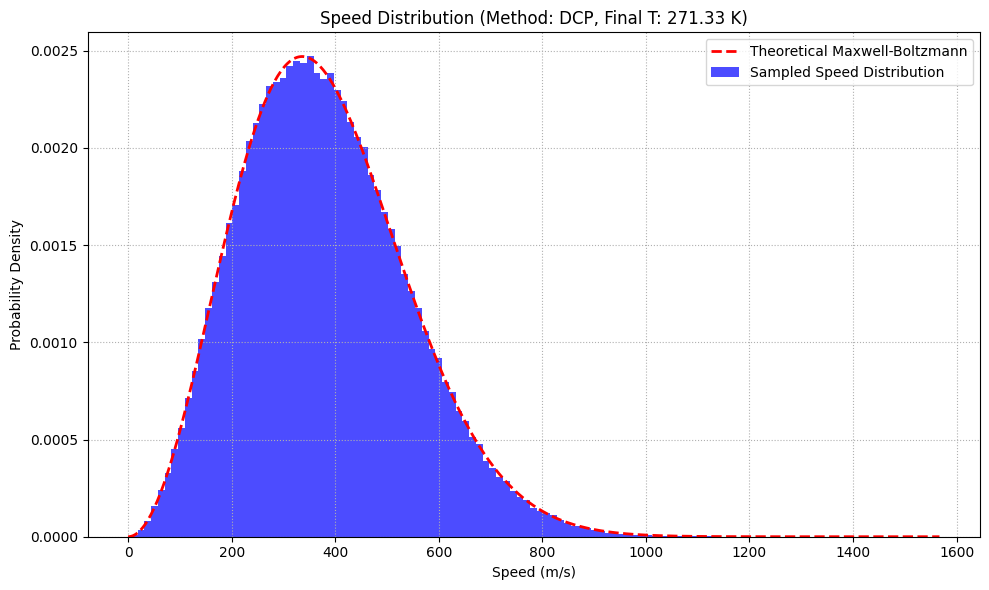

In [2]:
# -*- coding: utf-8 -*-
# --- DSMC RELAXATION - V2.1 - Interactive Choice & Updated Parameters ---
# This version prompts the user to choose a collision method and sets PPC=5.

import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit, prange # Ensure prange is imported for parallel loops
import time
from scipy.signal import savgol_filter
import pandas as pd
import warnings # Import the warnings module
from numba.core.errors import NumbaPerformanceWarning # For Numba specific warnings

# Suppress the specific NumbaPerformanceWarning
warnings.simplefilter('ignore', category=NumbaPerformanceWarning)
# Suppress RuntimeWarning for "Mean of empty slice"
warnings.filterwarnings("ignore", message="Mean of empty slice", category=RuntimeWarning)


# --- Constants and Physical Parameters ---
KB = 1.380649e-23  # Boltzmann constant (J/K)
MASS_AR = 39.948e-3 / 6.022e23 # Mass of Argon atom (kg)
D_REF_AR = 4.17e-10      # Diameter of Argon atom (m) - collision cross-section (used as sigma in quantumWeighted)
T_REF_AR = 273.0
OMEGA_VHS = 0.81

# --- SIMULATION PARAMETERS ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 600
PARTICLES_PER_CELL_INIT = 5  # <<< MODIFIED as per user request
TOTAL_PARTICLES_SIM = NUM_CELLS_X * PARTICLES_PER_CELL_INIT
N_DENSITY_REAL = RHO_INIT / MASS_AR
CELL_VOLUME_CONCEPTUAL = (LX**3) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 1.0e-12
TOTAL_TIME = 3.0e-8
SAMPLING_START_TIME = 5.0e-9
SAMPLING_INTERVAL = 2

# --- Helper functions from Expansion_HighestWeight.py (needed for perform_collisions_low_density_vhs_biased logic) ---

@njit
def generate_pairs_and_weights_distance_based(cell_particles_list, cell_counts, ci, cj, x_all, y_all, vx, vy, vz, epsilon=1e-10, distance_bias_power=1.0):
    """
    Generates all unique pairs within a cell and calculates their weights based on distance.
    Higher weight reflects closer distances.

    Args:
        cell_particles_list: 3D array of particle IDs in cells.
        cell_counts: 2D array of particle counts per cell.
        ci, cj: Cell indices.
        x_all, y_all: Global arrays of all particle x and y positions.
        vx, vy, vz: Global arrays of all particle velocities (needed for relative speed, if combined).
        epsilon: Small value to prevent division by zero for identical positions.
        distance_bias_power: Exponent to control the strength of the distance bias.
                             A higher value means a stronger bias towards closer particles.

    Returns:
        pairs: 2D array of particle ID pairs.
        weights: 1D array of weights for each pair.
    """
    Nc = cell_counts[ci, cj]
    if Nc < 2:
        return np.empty((0, 2), dtype=np.int32), np.empty(0, dtype=np.float64)
    max_pairs = Nc * (Nc - 1) // 2
    pairs = np.empty((max_pairs, 2), dtype=np.int32)
    weights = np.empty(max_pairs, dtype=np.float64)
    pair_count = 0
    for i in range(Nc):
        p_a_id = cell_particles_list[ci, cj, i]
        if p_a_id == -1:
            continue
        for k in range(i + 1, Nc):
            p_b_id = cell_particles_list[ci, cj, k]
            if p_b_id == -1:
                continue
            dist_x = x_all[p_a_id] - x_all[p_b_id]
            dist_y = y_all[p_a_id] - y_all[p_b_id]
            distance = np.sqrt(dist_x**2 + dist_y**2)

            denominator = (distance + epsilon)
            if denominator < 1e-12:
                denominator = 1e-12

            weight = 1.0 / (denominator**distance_bias_power)

            pairs[pair_count, 0] = p_a_id
            pairs[pair_count, 1] = p_b_id
            weights[pair_count] = weight
            pair_count += 1
    return pairs[:pair_count], weights[:pair_count]

@njit(parallel=True)
def build_cell_particle_lists(cell_indices, N, Nx, Ny, max_particles_per_cell):
    """
    Populates arrays that store particle IDs within each cell.
    Returns cell_counts (number of particles in each cell) and cell_particles (particle IDs).
    This function is generic and works for Ny=1 naturally.
    """
    cell_counts = np.zeros((Nx, Ny), dtype=np.int32)
    cell_particles = -1 * np.ones((Nx, Ny, max_particles_per_cell), dtype=np.int32)

    for p_idx in range(N):
        ci = cell_indices[p_idx]
        cj = 0 # For 1D simulation, y-cell index is always 0
        current_count = cell_counts[ci, cj]
        if current_count < max_particles_per_cell:
            cell_particles[ci, cj, current_count] = p_idx
            cell_counts[ci, cj] += 1
    return cell_counts, cell_particles

# --- VHS cross-section (adapted to use constants from maxwel.py) ---
@njit(nopython=True)
def calculate_vhs_cross_section_numba(vr_mag):
    """Calculates the collision cross-section using the VHS model."""
    if vr_mag < 1e-9: return 1e-30
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = 1.04533
    d_sq = (D_REF_AR**2) * ((c_ref_sq / vr_mag**2)**exponent) * (1 / gamma_val)
    return np.pi * d_sq

# --- Maxwell-Boltzmann distribution and related functions ---
@njit
def maxwell_boltzmann_velocity(temperature, mass, rng_state):
    """Generates a velocity component from a Maxwell-Boltzmann distribution."""
    sigma_v = np.sqrt(KB * temperature / mass)
    return rng_state.normal(0.0, sigma_v)

@njit
def initialize_particles_non_equilibrium(rng_state):
    """Initializes particles with a non-equilibrium velocity distribution (e.g., cold at one end, hot at other)."""
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4), dtype=np.float64) # x, vx, vy, vz

    # Simple uniform spatial distribution for now
    # FIX: Numba does not support 'endpoint=False' for np.linspace.
    # Use np.arange and scale to achieve the same result.
    particles[:, 0] = np.arange(TOTAL_PARTICLES_SIM) * (LX / TOTAL_PARTICLES_SIM) # X positions

    # Initial velocities from Maxwell-Boltzmann distribution at T_INIT
    for i in range(TOTAL_PARTICLES_SIM):
        particles[i, 1] = maxwell_boltzmann_velocity(T_INIT, MASS_AR, rng_state) # vx
        particles[i, 2] = maxwell_boltzmann_velocity(T_INIT, MASS_AR, rng_state) # vy
        particles[i, 3] = maxwell_boltzmann_velocity(T_INIT, MASS_AR, rng_state) # vz

    # Center the velocities to remove any bulk velocity
    mean_vx = np.mean(particles[:, 1])
    mean_vy = np.mean(particles[:, 2])
    mean_vz = np.mean(particles[:, 3])
    particles[:, 1] -= mean_vx
    particles[:, 2] -= mean_vy
    particles[:, 3] -= mean_vz

    return particles

@njit
def classical_sample_pair_index_from_weights(weights, rng_state):
    """
    Samples an index from a given array of weights using classical method.
    Returns the index or -1 if no valid index can be sampled.
    """
    if len(weights) == 0 or np.sum(weights) == 0:
        return -1

    cumulative_weights = np.cumsum(weights)
    total_weight = cumulative_weights[-1]

    if total_weight <= 0: # Avoid issues with all zero or negative weights
        return -1

    rand_val = rng_state.random() * total_weight

    # Find the index where rand_val falls
    for idx in range(len(cumulative_weights)):
        if rand_val < cumulative_weights[idx]:
            return idx
    return -1 # Should ideally not be reached if total_weight > 0


@njit(nopython=True)
def perform_collisions_sbt_numba(particles, indices_in_cell, cell_vol, dt, fnum, rng_state):
    """
    Performs collisions in a single cell using the Simplified Bernoulli Trials (SBT) method.
    Adapted for 1D cell structure where Ny=1.
    """
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0.0 # No collisions possible

    # Collect all possible pairs and their collision probabilities
    possible_pairs = []
    collision_probabilities = []

    max_prob_in_step = 0.0

    for i in range(num_particles_in_cell):
        p_a_id = indices_in_cell[i]
        for j in range(i + 1, num_particles_in_cell):
            p_b_id = indices_in_cell[j]

            # Calculate relative velocity
            vr_x = particles[p_a_id, 1] - particles[p_b_id, 1]
            vr_y = particles[p_a_id, 2] - particles[p_b_id, 2]
            vr_z = particles[p_a_id, 3] - particles[p_b_id, 3]
            vr_mag = np.sqrt(vr_x**2 + vr_y**2 + vr_z**2)

            if vr_mag < 1e-9: # Avoid division by zero for stationary particles
                continue

            # Calculate collision cross-section (VHS model)
            sigma_t_vhs = calculate_vhs_cross_section_numba(vr_mag)

            # Calculate collision probability for this pair
            pair_prob = (fnum * sigma_t_vhs * vr_mag * dt) / cell_vol

            if pair_prob > max_prob_in_step:
                max_prob_in_step = pair_prob

            possible_pairs.append((p_a_id, p_b_id))
            collision_probabilities.append(pair_prob)

    # Perform Bernoulli trials for each pair
    if max_prob_in_step > 0:
        for k in range(len(possible_pairs)):
            if rng_state.random() < collision_probabilities[k] / max_prob_in_step:
                # Collision occurs for this pair
                p_a_id, p_b_id = possible_pairs[k]

                vr_x = particles[p_a_id, 1] - particles[p_b_id, 1]
                vr_y = particles[p_a_id, 2] - particles[p_b_id, 2]
                vr_z = particles[p_a_id, 3] - particles[p_b_id, 3]
                vr_mag = np.sqrt(vr_x**2 + vr_y**2 + vr_z**2)

                # Inelastic collision for Maxwell molecules, just change direction
                # For VHS, we use standard collision mechanics
                vcm = 0.5 * (particles[p_a_id, 1:4] + particles[p_b_id, 1:4])

                # Random angles for post-collision relative velocity
                cos_chi = 2 * rng_state.random() - 1.0
                sin_chi = np.sqrt(1.0 - cos_chi**2)
                phi_chi = 2.0 * np.pi * rng_state.random()

                # New relative velocity components
                vr_prime = np.array([
                    vr_mag * sin_chi * np.cos(phi_chi),
                    vr_mag * sin_chi * np.sin(phi_chi),
                    vr_mag * cos_chi
                ])

                # Assign new velocities
                particles[p_a_id, 1:4] = vcm + 0.5 * vr_prime
                particles[p_b_id, 1:4] = vcm - 0.5 * vr_prime

    return max_prob_in_step


@njit(nopython=True)
def perform_collisions_dcp_numba(particles, indices_in_cell, cell_vol, dt, fnum, rng_state,
                                 fractional_collisions_accumulator, collision_separation_sum_per_cell,
                                 collision_count_per_cell, ci_current, cj_current): # Added ci_current, cj_current
    """
    Performs collisions for a single cell using the distance-biased pair selection
    and VHS collision mechanics, exactly like perform_collisions_low_density_vhs_biased.
    MODIFIED: Selects the pair with the maximum weight (closest pair) for each collision.
    """
    # For compatibility, we'll treat indices_in_cell as the particles in a single cell.
    # We need to create dummy cell_particles_list_3d and cell_counts_2d for generate_pairs_and_weights_distance_based
    # This assumes we are calling this function per cell, as perform_collisions_low_density_vhs_biased expects.
    # The current structure of maxwel.py iterates through cells, so this fits.

    num_particles_in_main_cell = len(indices_in_cell)

    if num_particles_in_main_cell < 2:
        return 0.0 # Return 0.0 for max_prob_in_step compatibility with maxwel.py

    # Create dummy cell_particles_list_3d and cell_counts_2d for the current cell
    # This is a bit of a workaround to use the existing `generate_pairs_and_weights_distance_based`
    # which expects a 3D list and 2D counts.
    # Since we are already processing one cell (i.e., indices_in_cell),
    # we can construct a minimal cell_particles_list_3d and cell_counts_2d for it.
    max_particles_per_cell_buffer = num_particles_in_main_cell # Buffer size just for this cell's particles
    dummy_cell_particles_list_3d = -1 * np.ones((1, 1, max_particles_per_cell_buffer), dtype=np.int32)
    dummy_cell_counts_2d = np.zeros((1, 1), dtype=np.int32)

    if num_particles_in_main_cell > 0:
        dummy_cell_particles_list_3d[0, 0, :num_particles_in_main_cell] = indices_in_cell
        dummy_cell_counts_2d[0, 0] = num_particles_in_main_cell

    # Parameters for generate_pairs_and_weights_distance_based
    ci_dummy = 0 # Dummy index for the single cell being processed within generate_pairs_and_weights_distance_based
    cj_dummy = 0 # Dummy index for the single cell being processed within generate_pairs_and_weights_distance_based
    epsilon_val = 1e-10
    distance_bias_power = 2.0 # Default from Expansion_HighestWeight.py example

    pairs, weights = generate_pairs_and_weights_distance_based(
        dummy_cell_particles_list_3d, dummy_cell_counts_2d, ci_dummy, cj_dummy, # Use dummy indices here
        particles[:, 0], np.zeros_like(particles[:, 0]), # x_all, dummy y_all (for 1D sim)
        particles[:, 1], particles[:, 2], particles[:, 3], # vx, vy, vz
        epsilon=epsilon_val,
        distance_bias_power=distance_bias_power
    )

    if len(pairs) == 0:
        return 0.0 # Return 0.0 for max_prob_in_step compatibility

    # Recalculate sum of (VHS cross-section * relative velocities) for the NTC collision count
    sum_of_sigma_g_for_ntc = 0.0
    for pair_idx in range(len(pairs)):
        p_a_id, p_b_id = pairs[pair_idx]
        vr_x = particles[p_a_id, 1] - particles[p_b_id, 1]
        vr_y = particles[p_a_id, 2] - particles[p_b_id, 2]
        vr_z = particles[p_a_id, 3] - particles[p_b_id, 3]
        vr_mag = np.sqrt(vr_x**2 + vr_y**2 + vr_z**2)

        if vr_mag > 1e-9:
            sigma_t_vhs = calculate_vhs_cross_section_numba(vr_mag)
            sum_of_sigma_g_for_ntc += sigma_t_vhs * vr_mag

    # Calculate expected collisions for this cell based on NTC
    expected_collisions_float = sum_of_sigma_g_for_ntc * (fnum * dt / cell_vol)

    # Handle fractional collisions accumulator - MODIFIED TO USE ci_current, cj_current
    expected_collisions_float += fractional_collisions_accumulator[ci_current, cj_current]
    n_coll_candidates_quantum = int(expected_collisions_float)
    fractional_collisions_accumulator[ci_current, cj_current] = expected_collisions_float - n_coll_candidates_quantum

    if n_coll_candidates_quantum <= 0:
        return 0.0 # Return 0.0 for max_prob_in_step compatibility

    # Perform actual collisions
    max_prob_in_step_for_return = 0.0 # To mimic the return value of SBT in maxwel.py
    for _ in range(n_coll_candidates_quantum):
        # Find the index of the maximum weight
        if np.max(weights) <= 0.0:
            break

        selected_idx = np.argmax(weights)

        if weights[selected_idx] <= 0.0:
            break

        p_a_id, p_b_id = pairs[selected_idx]

        # --- Inlined VHS Collision Mechanics ---
        vr_x = particles[p_a_id, 1] - particles[p_b_id, 1]
        vr_y = particles[p_a_id, 2] - particles[p_b_id, 2]
        vr_z = particles[p_a_id, 3] - particles[p_b_id, 3]
        vr_mag = np.sqrt(vr_x**2 + vr_y**2 + vr_z**2)

        if vr_mag < 1e-9:
            weights[selected_idx] = 0.0 # Still mark as used
            continue

        vcm = 0.5 * (particles[p_a_id, 1:4] + particles[p_b_id, 1:4])
        cos_chi = 2 * rng_state.random() - 1.0
        sin_chi = np.sqrt(1.0 - cos_chi**2)
        phi_chi = 2.0 * np.pi * rng_state.random()
        vr_prime = np.array([vr_mag * sin_chi * np.cos(phi_chi), vr_mag * sin_chi * np.sin(phi_chi), vr_mag * cos_chi])

        particles[p_a_id, 1:4] = vcm + 0.5 * vr_prime
        particles[p_b_id, 1:4] = vcm - 0.5 * vr_prime
        # --- End Inlined VHS Collision Mechanics ---

        weights[selected_idx] = 0.0 # Set weight to zero after selection to avoid re-selecting

        # --- Accumulate actual collision separation (NEW in Expansion_HighestWeight.py) ---
        collision_distance = np.abs(particles[p_a_id, 0] - particles[p_b_id, 0])
        collision_separation_sum_per_cell[ci_current, cj_current] += collision_distance # MODIFIED
        collision_count_per_cell[ci_current, cj_current] += 1 # MODIFIED
        # --- End NEW ---
        # For max_prob_in_step_for_return, we could calculate it, but since this method is deterministic
        # in its pair selection per NTC count, a conceptual max_prob_in_step isn't strictly applicable in the same way as SBT.
        # Returning 0.0 aligns with the original DCP function's return for max_prob_in_step.

    return max_prob_in_step_for_return

# --- Plotting functions ---
def plot_speed_distribution(sampled_speeds, final_temp, collision_method):
    """
    Plots the sampled speed distribution against the theoretical Maxwell-Boltzmann distribution.
    """
    plt.figure(figsize=(10, 6))

    # Plot histogram of sampled speeds
    hist, bin_edges = np.histogram(sampled_speeds, bins=100, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.bar(bin_centers, hist, width=bin_edges[1] - bin_edges[0], color='blue', alpha=0.7, label='Sampled Speed Distribution')

    # Plot theoretical Maxwell-Boltzmann distribution
    v_theoretical = np.linspace(0, np.max(bin_centers) * 1.2, 500)
    mb_dist = (MASS_AR / (2 * np.pi * KB * final_temp))**(3/2) * 4 * np.pi * v_theoretical**2 * np.exp(-MASS_AR * v_theoretical**2 / (2 * KB * final_temp))
    plt.plot(v_theoretical, mb_dist, color='red', linestyle='--', linewidth=2, label='Theoretical Maxwell-Boltzmann')

    plt.xlabel('Speed (m/s)')
    plt.ylabel('Probability Density')
    plt.title(f'Speed Distribution (Method: {collision_method}, Final T: {final_temp:.2f} K)')
    plt.grid(True, linestyle=':')
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Main Simulation Driver ---
def run_dsmc_simulation(collision_method='SBT'):
    print(f"--- DSMC Relaxation to Maxwell-Boltzmann ---")
    print(f"--- Using Collision Method: {collision_method} ---")
    print(f"--- Particles per Cell: {PARTICLES_PER_CELL_INIT} ---")

    rng_state = np.random.default_rng()
    particles = initialize_particles_non_equilibrium(rng_state)

    sampled_speeds_accumulator = []
    max_overall_prob = 0.0

    start_time = time.time()
    print("\nStarting main simulation loop...")
    num_steps = int(TOTAL_TIME / DT)
    sampling_start_step = int(SAMPLING_START_TIME / DT)
    cell_width = LX / NUM_CELLS_X

    # Initialize fractional collision accumulator for all cells (for DCP) - MODIFIED TO BE 2D
    # And collision separation accumulators. - MODIFIED TO BE 2D
    fractional_collisions_accumulator = np.zeros((NUM_CELLS_X, 1), dtype=np.float64)
    collision_separation_sum_per_cell = np.zeros((NUM_CELLS_X, 1), dtype=np.float64)
    collision_count_per_cell = np.zeros((NUM_CELLS_X, 1), dtype=np.int64)


    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX # Apply periodic boundary conditions

        # Recalculate cell indices after particle movement
        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)

        # Sort particles by cell for efficient processing
        sorted_particle_indices = np.argsort(cell_indices)

        # Determine particle counts and starting indices for each cell
        cell_counts_bincount = np.bincount(cell_indices, minlength=NUM_CELLS_X) # Renamed to avoid clash with build_cell_particle_lists output
        cell_start_indices = np.concatenate(([0], np.cumsum(cell_counts_bincount[:-1])))

        current_max_prob = 0.0
        # Build cell particle lists once per step for DCP
        max_particles_per_cell_buffer = int(2.0 * TOTAL_PARTICLES_SIM / NUM_CELLS_X) + 50 # Ensure buffer is large enough
        cell_counts_2d, cell_particles_list_3d = build_cell_particle_lists(
            cell_indices, particles.shape[0], NUM_CELLS_X, 1, max_particles_per_cell_buffer
        )

        for i in range(NUM_CELLS_X):
            num_particles_in_main_cell = cell_counts_2d[i, 0] # Use the 2D cell_counts

            if num_particles_in_main_cell < 2:
                continue

            # Original `maxwel.py` uses indices_in_cell_i from sorted_particle_indices.
            # `Expansion_HighestWeight.py` uses `cell_particles_list_3d`.
            # For DCP, `generate_pairs_and_weights_distance_based` needs to be called
            # with dummy arrays if the `perform_collisions_dcp_numba` is called per cell as it is now.
            # The current structure of `perform_collisions_dcp_numba` already constructs dummy `cell_particles_list_3d`
            # and `cell_counts_2d` internally from `indices_in_cell`. So, we continue to pass `indices_in_cell_i`.

            indices_in_cell_i = sorted_particle_indices[cell_start_indices[i]:cell_start_indices[i]+num_particles_in_main_cell]

            if collision_method == 'SBT':
                max_p = perform_collisions_sbt_numba(particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state)
            elif collision_method == 'DCP':
                # Pass the entire accumulator arrays and current cell indices - MODIFIED
                max_p = perform_collisions_dcp_numba(
                    particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state,
                    fractional_collisions_accumulator, # Pass entire array
                    collision_separation_sum_per_cell, # Pass entire array
                    collision_count_per_cell, # Pass entire array
                    i, 0 # ci_current, cj_current
                )
            else:
                max_p = 0.0 # Should not happen with current choice mechanism

            if max_p > current_max_prob:
                current_max_prob = max_p

        if current_max_prob > max_overall_prob:
            max_overall_prob = current_max_prob

        # Sampling for speed distribution
        if step >= sampling_start_step and step % SAMPLING_INTERVAL == 0:
            speeds = np.sqrt(np.sum(particles[:, 1:4]**2, axis=1))
            sampled_speeds_accumulator.extend(speeds)

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps}...")

    end_time = time.time()
    print(f"Simulation finished in {end_time - start_time:.2f} seconds.\n")

    if max_overall_prob > 1.0:
        print(f"WARNING: Maximum collision probability reached {max_overall_prob:.3f}.")
        print("This is unphysical. The time step (DT) should be reduced.")
    else:
        print(f"Collision probability check passed (max prob = {max_overall_prob:.3f}).")

    final_temp = (2.0/3.0) * (0.5 * MASS_AR * np.sum(particles[:, 1:4]**2) / TOTAL_PARTICLES_SIM) / KB
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")

    if sampled_speeds_accumulator:
        plot_speed_distribution(np.array(sampled_speeds_accumulator), final_temp, collision_method)
    else:
        print("No speed data was sampled. Check SAMPLING_START_TIME and TOTAL_TIME.")

# ===================================================================
if __name__ == "__main__":
    # <<< MODIFIED: Interactive choice for collision method >>>
    while True:
        choice = input("Please choose the collision method:\n  [1] Simplified Bernoulli Trials (SBT)\n  [2] Deterministic Closest-Pair (DCP)\nEnter choice (1 or 2): ")
        if choice == '1':
            SELECTED_METHOD = 'SBT'
            break
        elif choice == '2':
            SELECTED_METHOD = 'DCP'
            break
        else:
            print("Invalid input. Please enter 1 or 2.")

    run_dsmc_simulation(collision_method=SELECTED_METHOD)